# EfficientSAM -> TFLite (Android)

Exports the **interactive prompt** path -- box or click prompts, the flow from
`EfficientSAM_example.ipynb` -- as a split encoder / decoder `.tflite` pair for
Android.

This is the TFLite sibling of `EfficientSAM_prompt_coreml_export.ipynb`. The
wrapper modules are **identical**; only the converter differs. Two rewrites that
were forced by Core ML turn out to be portable wins:

| rewrite | why it was needed for Core ML | on TFLite |
|---|---|---|
| positional embedding folded into a buffer | no `upsample_bicubic2d` converter | still folded -- one less runtime op |
| normalization folded into the graph | correctness, not support | same -- Android passes plain `[0, 1]` RGB |
| in-graph IoU sort | worked fine there | **removed** -- no TFLite kernel for `STABLEHLO_SORT` |

That last row is the one real portability difference, and it is a runtime gap
rather than a converter gap: the decoder converts and writes a valid `.tflite`
either way, then fails when the interpreter is built. Ranking moved to host
code, so the exported decoder returns candidates **unsorted**.

### Environment

`litert-torch` needs **torch >= 2.6** (it imports `torch.int1`). The repo's
Core ML environment pins torch 2.4.1, so this notebook must run in a separate
env -- installing litert-torch beside coremltools upgrades numpy past 2.0 and
breaks the torch 2.4.1 install:

```bash
conda create -y -n tflite python=3.11
conda activate tflite
pip install litert-torch matplotlib
```

Do **not** install torchvision in this env. Its wheels are pinned to an exact
torch build, pip resolves the pin by upgrading torch, and the result is an
import-time `RuntimeError: operator torchvision::nms does not exist`. The one
thing this notebook wanted from it (`ToTensor`) is four lines of numpy.

Run this notebook with the `tflite` kernel, not the base one.

## Setup

In [4]:
import os, sys, time

# Run from the repo root so "weights/" and "figs/" resolve.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
print(os.getcwd())

/Users/nuhash/Desktop/other-codes/EfficientSAM


In [5]:
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image

import litert_torch


def to_tensor(image_np):
    # Stand-in for torchvision's ToTensor, without the dependency. torchvision
    # wheels are pinned to an exact torch build, and litert-torch moves torch
    # faster than torchvision follows -- installing both here yields
    # "RuntimeError: operator torchvision::nms does not exist" at import.
    # HWC uint8 [0,255] -> CHW float32 [0,1].
    return torch.from_numpy(
        np.ascontiguousarray(image_np.transpose(2, 0, 1))
    ).float().div(255.0)

print("torch       ", torch.__version__)
print("numpy       ", np.__version__)

# litert-torch needs torch>=2.6 for torch.int1. Fail loudly rather than
# halfway through a 10 minute conversion.
_major, _minor = (int(x) for x in torch.__version__.split(".")[:2])
assert (_major, _minor) >= (2, 6), (
    f"litert-torch needs torch>=2.6, found {torch.__version__}. "
    "Run this notebook in the dedicated 'tflite' env, not the Core ML one."
)

W0818 12:11:39.066000 55328 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:35] NOTE: Redirects are currently not supported in MacOs.
W0818 12:11:39.084000 55328 site-packages/torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


torch        2.12.1
numpy        2.4.6


/opt/anaconda3/envs/tflite/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Export configuration

Same contract as the Core ML prompt export: `NUM_POINTS = 2` covers a two-click
point prompt (`labels = [1, 1]`) and a box (`labels = [2, 3]` for top-left /
bottom-right). The wrapper pads to the model's
`decoder_max_num_input_points = 6` internally.

No quantization flag: `litert_torch.convert` has no fp16 weight option in
0.9.3 (`QuantConfig` covers PT2E int8 and generative-LLM recipes only). These
export as float32. See the quantization note at the end for what to do if size
matters.

In [6]:
MODEL_NAMES   = ["vitt", "vits"]  # vitt = 10M params, vits = 26M
ENCODER_SIZE  = 1024              # ViT native img_size (input is stretched to it)
NUM_POINTS    = 2                 # point-pair or box corners
OUTPUT_SIZE   = 256               # decoder logit resolution

OUT_DIR = "weights/tflite"
os.makedirs(OUT_DIR, exist_ok=True)


def paths_for(name):
    return (
        f"{OUT_DIR}/efficient_sam_{name}_prompt_encoder.tflite",
        f"{OUT_DIR}/efficient_sam_{name}_prompt_decoder.tflite",
    )


for n in MODEL_NAMES:
    print(" ".join(paths_for(n)))

weights/tflite/efficient_sam_vitt_prompt_encoder.tflite weights/tflite/efficient_sam_vitt_prompt_decoder.tflite
weights/tflite/efficient_sam_vits_prompt_encoder.tflite weights/tflite/efficient_sam_vits_prompt_decoder.tflite


## Load the PyTorch models

In [7]:
import zipfile
from efficient_sam.build_efficient_sam import (
    build_efficient_sam_vitt,
    build_efficient_sam_vits,
)

# The VIT-small checkpoint ships zipped because it is >100MB.
if not os.path.exists("weights/efficient_sam_vits.pt"):
    with zipfile.ZipFile("weights/efficient_sam_vits.pt.zip") as z:
        z.extractall("weights")

builders = {"vitt": build_efficient_sam_vitt, "vits": build_efficient_sam_vits}
pt_models = {name: builders[name]().eval() for name in MODEL_NAMES}

for name, m in pt_models.items():
    print(f"{name}: {sum(p.numel() for p in m.parameters())/1e6:.1f}M params")

vitt: 10.2M params
vits: 26.4M params


## Traceable wrappers

Byte-for-byte the same classes as the Core ML prompt export. Two things happen
inside the graph rather than in host code.

**Pixel normalization.** `EfficientSam.preprocess` applies
`(x - pixel_mean) / pixel_std` with ImageNet statistics before the ViT sees
anything. Folding it in means Android code passes a plain `[0, 1]` RGB tensor
and cannot get the normalization wrong.

**The positional embedding.** `get_abs_pos` bicubically resizes `pos_embed` to
the patch grid. The result is constant with respect to the input, so it is
computed once at construction and registered as a buffer.

In [8]:
from efficient_sam.efficient_sam_encoder import get_abs_pos


class PromptEncoderStage(torch.nn.Module):
    # Stretched 1024x1024 [0,1] image -> cached embedding. Runs once per image.

    def __init__(self, model):
        super().__init__()
        self.encoder = model.image_encoder
        # Fold preprocess() normalization into the graph.
        self.register_buffer("pixel_mean", model.pixel_mean.clone())
        self.register_buffer("pixel_std", model.pixel_std.clone())

        grid = self.encoder.img_size // self.encoder.patch_embed.proj.kernel_size[0]
        with torch.no_grad():
            abs_pos = get_abs_pos(
                self.encoder.pos_embed,
                self.encoder.pretrain_use_cls_token,
                [grid, grid],
            )
        # Constant w.r.t. the input: fold it in instead of recomputing per call.
        self.register_buffer("abs_pos", abs_pos)
        self.grid = grid

    def forward(self, image):
        # image: (1, 3, ENCODER_SIZE, ENCODER_SIZE), RGB in [0, 1]
        x = (image - self.pixel_mean) / self.pixel_std
        x = self.encoder.patch_embed(x)
        x = x.permute(0, 2, 3, 1)          # B C H W -> B H W C
        x = x + self.abs_pos
        n = self.grid
        x = x.reshape(x.shape[0], n * n, x.shape[3])
        for blk in self.encoder.blocks:
            x = blk(x)
        x = x.reshape(x.shape[0], n, n, x.shape[2])
        return self.encoder.neck(x.permute(0, 3, 1, 2))


class PromptDecoderStage(torch.nn.Module):
    # Cached embedding + one prompt -> 3 candidate masks + their IoU scores,
    # UNSORTED. The Core ML version sorts in the graph; that is not portable --
    # torch.argsort lowers to STABLEHLO_SORT, which the TFLite runtime has no
    # kernel for. Host code picks argmax over 3 floats instead.

    def __init__(self, model, output_size):
        super().__init__()
        self.model = model
        self.output_size = output_size
        self.max_pts = model.decoder_max_num_input_points

    def forward(self, image_embeddings, point_coords, point_labels):
        # point_coords: (1, 1, NUM_POINTS, 2) in 1024-space
        # point_labels: (1, 1, NUM_POINTS)  1=fg, 2=box TL, 3=box BR, -1=ignore
        batch_size, num_queries, num_pts, _ = point_coords.shape

        # Same pad/truncate convention as EfficientSam.predict_masks.
        if num_pts > self.max_pts:
            point_coords = point_coords[:, :, : self.max_pts, :]
            point_labels = point_labels[:, :, : self.max_pts]
        elif num_pts < self.max_pts:
            point_coords = F.pad(
                point_coords, (0, 0, 0, self.max_pts - num_pts), value=-1.0
            )
            point_labels = F.pad(
                point_labels, (0, self.max_pts - num_pts), value=-1.0
            )

        sparse_embeddings = self.model.prompt_encoder(
            point_coords.reshape(batch_size * num_queries, self.max_pts, 2),
            point_labels.reshape(batch_size * num_queries, self.max_pts),
        )
        sparse_embeddings = sparse_embeddings.view(
            batch_size, num_queries,
            sparse_embeddings.shape[1], sparse_embeddings.shape[2],
        )

        low_res_masks, iou_predictions = self.model.mask_decoder(
            image_embeddings,
            self.model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            multimask_output=True,
        )
        num_predictions = low_res_masks.shape[1]

        # Bilinear, matching the Core ML export, so the two mobile targets
        # produce the same masks. predict_masks upsamples bicubically.
        masks = F.interpolate(
            low_res_masks,
            (self.output_size, self.output_size),
            mode="bilinear",
            align_corners=False,
        )
        masks = masks.reshape(
            batch_size, num_queries, num_predictions,
            self.output_size, self.output_size,
        )
        iou_predictions = iou_predictions.reshape(
            batch_size, num_queries, num_predictions
        )

        # No in-graph sort. See the class comment: STABLEHLO_SORT has no TFLite
        # kernel, so the model exports fine and then fails at interpreter
        # construction with "Didn't find op for builtin opcode
        # 'STABLEHLO_SORT'". Ranking moves to host code.
        return masks, iou_predictions


wrappers = {
    name: (
        PromptEncoderStage(m).eval(),
        PromptDecoderStage(m, OUTPUT_SIZE).eval(),
    )
    for name, m in pt_models.items()
}
for name, (enc, _) in wrappers.items():
    print(f"{name}: folded abs_pos {tuple(enc.abs_pos.shape)}")

vitt: folded abs_pos (1, 64, 64, 192)
vits: folded abs_pos (1, 64, 64, 384)


Confirm the rewritten encoder still matches the stock forward pass before
converting anything. The reference is `get_image_embeddings`, which is the
**full** stock path including `preprocess` -- so this assert fails if the
normalization fold is wrong, rather than silently comparing two un-normalized
graphs.

In [9]:
_probe = torch.rand(1, 3, ENCODER_SIZE, ENCODER_SIZE)
for name in MODEL_NAMES:
    with torch.no_grad():
        ref = pt_models[name].get_image_embeddings(_probe)  # stock: preprocess + bicubic
        got = wrappers[name][0](_probe)                     # rewritten
    d = (ref - got).abs().max().item()
    print(f"{name}: max abs diff vs stock encoder = {d:.3e}")
    assert d < 1e-5, f"{name} rewrite diverges from the original"
print("\nOK - wrappers are faithful.")

vitt: max abs diff vs stock encoder = 0.000e+00
vits: max abs diff vs stock encoder = 0.000e+00

OK - wrappers are faithful.


## Convert

`litert_torch.convert` runs on `torch.export` rather than TorchScript, so the
sample inputs define the (static) input signature directly. Point coordinates
are passed in **1024-space** and rescaled by host code, which keeps image
dimensions out of the graph -- one exported model works for any input
resolution.

The encoder is the expensive conversion: a 1024x1024 ViT with 12 attention
blocks. Expect minutes per model, not seconds.

In [10]:
def convert_pair(name):
    enc_w, dec_w = wrappers[name]
    enc_path, dec_path = paths_for(name)

    enc_sample = (torch.rand(1, 3, ENCODER_SIZE, ENCODER_SIZE),)
    with torch.no_grad():
        embed_shape = tuple(enc_w(*enc_sample).shape)

    t = time.time()
    edge_enc = litert_torch.convert(enc_w, enc_sample)
    edge_enc.export(enc_path)
    print(f"{name} encoder: {embed_shape} in {time.time()-t:.1f}s -> {enc_path}")

    dec_sample = (
        torch.rand(*embed_shape),
        torch.rand(1, 1, NUM_POINTS, 2) * ENCODER_SIZE,
        torch.ones(1, 1, NUM_POINTS),
    )
    t = time.time()
    edge_dec = litert_torch.convert(dec_w, dec_sample)
    edge_dec.export(dec_path)
    print(f"{name} decoder: converted in {time.time()-t:.1f}s -> {dec_path}")
    return edge_enc, edge_dec, embed_shape


edge_models = {}
for name in MODEL_NAMES:
    edge_models[name] = convert_pair(name)

(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

/opt/anaconda3/envs/tflite/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


(00:00) [ DONE] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions (+00:00)

...

(00:04) [ DONE] LiteRT-Torch Convert (+00:04)

(00:00) [START] Write Model to weights/tflite/efficient_sam_vits_prompt_decoder.tflite

I0000 00:00:1787033528.281693 3815844 flatbuffer_export.cc:4342] Estimated count of arithmetic ops: 3.698 G  ops, equivalently 1.849 G  MACs


(00:00) [ DONE] Write Model to weights/tflite/efficient_sam_vits_prompt_decoder.tflite (+00:00)

vits decoder: converted in 4.8s -> weights/tflite/efficient_sam_vits_prompt_decoder.tflite


In [11]:
for name in MODEL_NAMES:
    enc_path, dec_path = paths_for(name)
    e, d = os.path.getsize(enc_path)/1e6, os.path.getsize(dec_path)/1e6
    print(f"{name:5}  encoder {e:7.1f} MB   decoder {d:6.1f} MB   total {e+d:7.1f} MB")

vitt   encoder    27.8 MB   decoder   20.6 MB   total    48.4 MB
vits   encoder    95.5 MB   decoder   20.6 MB   total   116.2 MB


## Fidelity: TFLite vs PyTorch

Conversion succeeding says nothing about correctness. What matters for a
segmentation model is not the raw logit error but whether the **binarized mask**
changes -- a logit that shifts from 3.1 to 3.0 is invisible, one that crosses
zero flips a pixel.

In [12]:
for name in MODEL_NAMES:
    edge_enc, edge_dec, embed_shape = edge_models[name]
    enc_w, dec_w = wrappers[name]

    probe = torch.rand(1, 3, ENCODER_SIZE, ENCODER_SIZE)
    with torch.no_grad():
        ref_embed = enc_w(probe).numpy()
    got_embed = np.asarray(edge_enc(probe))

    denom = np.abs(ref_embed).mean()
    print(f"{name} embedding: max abs err {np.abs(ref_embed-got_embed).max():.5f}  "
          f"mean {np.abs(ref_embed-got_embed).mean():.6f} "
          f"({np.abs(ref_embed-got_embed).mean()/denom*100:.3f}% of mean magnitude)")

    pts = torch.rand(1, 1, NUM_POINTS, 2) * ENCODER_SIZE
    labels = torch.ones(1, 1, NUM_POINTS)
    with torch.no_grad():
        ref_masks, ref_iou = dec_w(torch.from_numpy(ref_embed), pts, labels)
    got = edge_dec(torch.from_numpy(ref_embed), pts, labels)
    got_masks, got_iou = (np.asarray(x) for x in got)

    agree = ((ref_masks.numpy() >= 0) == (got_masks >= 0)).mean() * 100
    print(f"{name} decoder  : binarized agreement {agree:.3f}%  "
          f"iou_pred max err {np.abs(ref_iou.numpy()-got_iou).max():.5f}")
    assert agree > 99.0, f"{name}: TFLite conversion changed masks materially"
print("\nOK - TFLite export is faithful.")

(00:00) [START] Write Model to Bytes

I0000 00:00:1787033529.218617 3815844 flatbuffer_export.cc:4342] Estimated count of arithmetic ops: 89.350 G  ops, equivalently 44.675 G  MACs


(00:00) [ DONE] Write Model to Bytes (+00:00)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
ERROR: Subgraph reshaping is enabled by default, TFLITE_XNNPACK_DELEGATE_FLAG_ENABLE_SUBGRAPH_RESHAPING is deprecated and will be removed in the future.


vitt embedding: max abs err 0.00000  mean 0.000000 (0.000% of mean magnitude)


...

vits embedding: max abs err 0.00000  mean 0.000000 (0.000% of mean magnitude)


(00:00) [START] Write Model to Bytes

I0000 00:00:1787033533.140983 3815844 flatbuffer_export.cc:4342] Estimated count of arithmetic ops: 3.698 G  ops, equivalently 1.849 G  MACs


(00:00) [ DONE] Write Model to Bytes (+00:00)

vits decoder  : binarized agreement 100.000%  iou_pred max err 0.00000

OK - TFLite export is faithful.


## End-to-end on a real image

The same prompts the Core ML notebook validates against, so the three backends
(PyTorch / Core ML / TFLite) are directly comparable.

Host-side contract, which Android code must reproduce exactly:

1. **Stretch** to 1024x1024 -- bilinear, aspect ratio *not* preserved.
2. Scale prompt coordinates **per axis**: `x * 1024/width`, `y * 1024/height`.
   A single uniform factor is only correct for square images.
3. Take **argmax** over the returned IoU scores. Unlike the Core ML export,
   this graph returns candidates unsorted.

In [13]:
def encode_image(image_np, edge_enc):
    # Stretch to 1024, run the encoder once, return the cached embedding.
    img = to_tensor(image_np)[None, ...]  # (1, 3, H, W) in [0, 1]
    resized = F.interpolate(
        img, (ENCODER_SIZE, ENCODER_SIZE), mode="bilinear", align_corners=False
    )
    return np.asarray(edge_enc(resized)), img.shape[2], img.shape[3]


def decode_prompt(embedding, pts, labels, orig_h, orig_w, edge_dec):
    # pts: (NUM_POINTS, 2) in original-image pixels. Returns (bool mask, iou).
    pts = np.asarray(pts, dtype=np.float32).reshape(1, 1, -1, 2)
    labels = np.asarray(labels, dtype=np.float32).reshape(1, 1, -1)
    assert pts.shape[2] == NUM_POINTS, f"exported model wants {NUM_POINTS} points"

    # Per-axis scale: the encoder input is a stretch, not a uniform resize.
    scaled = pts.copy()
    scaled[..., 0] *= ENCODER_SIZE / orig_w
    scaled[..., 1] *= ENCODER_SIZE / orig_h

    masks, ious = edge_dec(
        torch.from_numpy(embedding.astype(np.float32)),
        torch.from_numpy(scaled),
        torch.from_numpy(labels),
    )
    masks, ious = np.asarray(masks), np.asarray(ious)

    # The graph does NOT sort (no STABLEHLO_SORT kernel), so rank here. This is
    # the one line Android has to reproduce: argmax over a handful of floats.
    k = int(np.argmax(ious[0, 0]))
    best = torch.from_numpy(masks)[:, 0, k : k + 1]   # (1, 1, 256, 256)
    full = F.interpolate(best, (orig_h, orig_w), mode="bilinear", align_corners=False)
    return (full[0, 0] >= 0).numpy(), float(ious[0, 0, k])


def run_tflite_box_or_points(img_path, pts, labels, name):
    edge_enc, edge_dec, _ = edge_models[name]
    image_np = np.array(Image.open(img_path))
    embedding, h, w = encode_image(image_np, edge_enc)
    return decode_prompt(embedding, pts, labels, h, w, edge_dec)

In [14]:
def run_pytorch_box_or_points(img_path, pts, labels, model):
    # run_ours_box_or_points from EfficientSAM_example.ipynb, verbatim.
    image_np = np.array(Image.open(img_path))
    img_tensor = to_tensor(image_np)
    pts_sampled = torch.reshape(torch.tensor(pts), [1, 1, -1, 2])
    pts_labels = torch.reshape(torch.tensor(labels), [1, 1, -1])
    predicted_logits, predicted_iou = model(
        img_tensor[None, ...], pts_sampled, pts_labels
    )
    sorted_ids = torch.argsort(predicted_iou, dim=-1, descending=True)
    predicted_iou = torch.take_along_dim(predicted_iou, sorted_ids, dim=2)
    predicted_logits = torch.take_along_dim(
        predicted_logits, sorted_ids[..., None, None], dim=2
    )
    return (
        torch.ge(predicted_logits[0, 0, 0, :, :], 0).cpu().numpy(),
        float(predicted_iou[0, 0, 0]),
    )


IMAGE_PATH = "figs/examples/dogs.jpg"
PROMPTS = {
    "box":    (np.array([[400, 200], [800, 600]]), np.array([2, 3])),
    "points": (np.array([[580, 350], [650, 350]]), np.array([1, 1])),
}

results = {}
for name in MODEL_NAMES:
    for kind, (pts, labels) in PROMPTS.items():
        with torch.no_grad():
            pt_mask, pt_iou = run_pytorch_box_or_points(
                IMAGE_PATH, pts, labels, pt_models[name]
            )
        tf_mask, tf_iou = run_tflite_box_or_points(IMAGE_PATH, pts, labels, name)

        agree = (pt_mask == tf_mask).mean() * 100
        inter = np.logical_and(pt_mask, tf_mask).sum()
        union = np.logical_or(pt_mask, tf_mask).sum()
        iou = inter / union if union else 1.0
        results[(name, kind)] = (tf_mask, pt_mask, agree, iou)

        print(f"{name:5} {kind:6} pixel agreement {agree:6.3f}%  "
              f"mask IoU {iou:.4f}  iou_pred pt={pt_iou:.3f} tf={tf_iou:.3f}")
        assert agree > 98.0, f"{name}/{kind} masks diverge too much"
print("\nOK - TFLite masks match PyTorch.")

vitt  box    pixel agreement 99.946%  mask IoU 0.9954  iou_pred pt=0.923 tf=0.923
vitt  points pixel agreement 99.951%  mask IoU 0.9958  iou_pred pt=0.901 tf=0.901
vits  box    pixel agreement 99.927%  mask IoU 0.9938  iou_pred pt=0.975 tf=0.975
vits  points pixel agreement 99.885%  mask IoU 0.9900  iou_pred pt=0.864 tf=0.864

OK - TFLite masks match PyTorch.


## Visual check

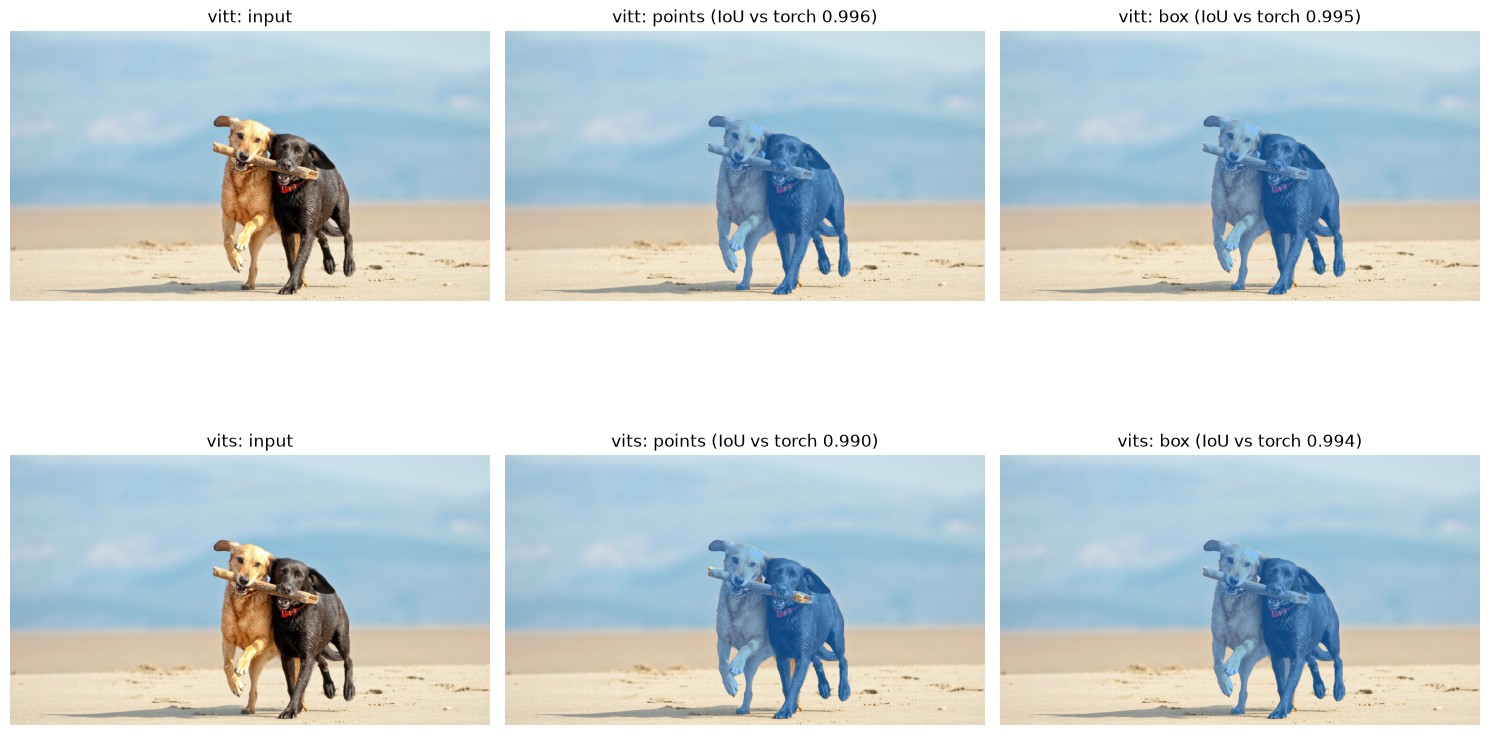

In [15]:
import matplotlib.pyplot as plt

image_np = np.array(Image.open(IMAGE_PATH))
fig, axes = plt.subplots(len(MODEL_NAMES), 3, figsize=(15, 5 * len(MODEL_NAMES)))
axes = np.atleast_2d(axes)

for row, name in enumerate(MODEL_NAMES):
    axes[row, 0].imshow(image_np)
    axes[row, 0].set_title(f"{name}: input")
    for col, kind in enumerate(["points", "box"], start=1):
        tf_mask, _, agree, iou = results[(name, kind)]
        overlay = image_np.copy()
        overlay[tf_mask] = (0.5 * overlay[tf_mask] +
                            0.5 * np.array([30, 144, 255])).astype(np.uint8)
        axes[row, col].imshow(overlay)
        axes[row, col].set_title(f"{name}: {kind} (IoU vs torch {iou:.3f})")

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

## Latency

`litert_torch` runs the exported model through the TFLite interpreter on this
machine's CPU. Treat these numbers as a **relative** encoder-vs-decoder
comparison, not a prediction of Android performance -- a phone's GPU delegate
has a completely different profile.

The point this measures is the one that makes the split export worth it: the
encoder dominates, and it runs **once per image** while the decoder runs once
per tap.

In [16]:
import statistics

REPS = 3
image_np = np.array(Image.open(IMAGE_PATH))
img = to_tensor(image_np)[None, ...]
resized = F.interpolate(img, (ENCODER_SIZE, ENCODER_SIZE),
                        mode="bilinear", align_corners=False)

for name in MODEL_NAMES:
    edge_enc, edge_dec, _ = edge_models[name]

    edge_enc(resized)  # warm up
    enc_times = []
    for _ in range(REPS):
        t = time.time(); edge_enc(resized); enc_times.append(time.time() - t)
    embedding = np.asarray(edge_enc(resized))

    pts = torch.rand(1, 1, NUM_POINTS, 2) * ENCODER_SIZE
    labels = torch.ones(1, 1, NUM_POINTS)
    emb_t = torch.from_numpy(embedding.astype(np.float32))
    edge_dec(emb_t, pts, labels)  # warm up
    dec_times = []
    for _ in range(REPS):
        t = time.time(); edge_dec(emb_t, pts, labels); dec_times.append(time.time() - t)

    print(f"{name:5} encoder {statistics.median(enc_times)*1000:8.1f} ms  (once per image)")
    print(f"{name:5} decoder {statistics.median(dec_times)*1000:8.1f} ms  (once per prompt)")

vitt  encoder    541.5 ms  (once per image)
vitt  decoder     28.0 ms  (once per prompt)
vits  encoder   1130.9 ms  (once per image)
vits  decoder     28.0 ms  (once per prompt)


## Notes for the Android side

**Input contract.** The encoder takes `(1, 3, 1024, 1024)` float32 RGB in
`[0, 1]`. Normalization is folded into the graph -- do **not** apply ImageNet
mean/std in Kotlin, it would be applied twice.

**Layout.** These are NCHW graphs. TFLite is natively NHWC, and the converter
inserts transposes at the boundary. If profiling shows those transposes costing
real time, the fix is to feed NHWC and transpose inside the wrapper's `forward`
rather than fighting the converter.

**Cache the embedding.** The whole reason for the split export: run the encoder
once per image, hold the `(1, 256, 64, 64)` float array, and pay only the
decoder per tap. Re-encoding per prompt is what makes a naive port unusable.

**Delegates.** `GpuDelegate` does **not** work for these graphs -- measured on
a Snapdragon 865, not assumed. It loads, claims 59 of the encoder's 636 nodes,
then builds zero kernels: `SLICE` requests version 5 against a max supported 2,
`RESHAPE`/`TRANSPOSE` report incompatible tensor shapes, and init fails with
"Batch size mismatch, expected 1 but got 3". Not a dynamic-shape issue -- both
graphs are fully static. It is op coverage in the ViT attention blocks.
Attempting it costs delegate init plus a failed interpreter construction before
falling back, which measurably slows encoding, so the Android demo defaults to
CPU/XNNPACK. NNAPI is deprecated as of Android 15; do not build on it either.
Re-check the GPU path if these wrappers are re-exported with different ops.

**Ranking is your job.** The decoder returns candidates unsorted. Take
`argmax` over the IoU vector -- see `decode_prompt` above. Blindly taking index
0, as the Core ML app does, gives an arbitrary candidate here.

**Quantization.** These cells export **float32**. `notebooks/export_quantized_tflite.py`
reuses the wrappers above to also emit fp16 and int8 builds via
`litert_torch.convert(..., quant_config=...)` with `quant_recipes.full_fp16_recipe`
and `full_dynamic_recipe` (which already defaults to channelwise int8, so no
separate per-channel step is needed). Encoder sizes: vitt 27.8 -> 15.6 -> 9.8 MB,
vits 95.5 -> 51.1 -> 29.4 MB. Fidelity against fp32 on `dogs.jpg`: fp16 is
effectively lossless, int8 stays above 99.9% binarized agreement and 98.3%
mask-IoU, and every variant picks the same candidate.

One trap, and it only appears on device: applying the int8 recipe to the
*decoder* produces a graph the desktop runtime accepts and Android refuses to
allocate -- `transpose_conv.cc:312 weights->type != input->type (INT8 !=
FLOAT32)`. The mask upsampler's `TRANSPOSE_CONV` needs weights matching its
float activations, so the int8 build quantizes the encoder only. On a budget
device (Exynos 850) int8 cut encode ~22% (vitt) to ~35% (vits); fp16 changed
nothing, because XNNPACK dequantizes to float32 to compute -- it is a download
size win only.

**The everything-mode models are not exported here.** This notebook covers the
prompt path only. The segment-everything export additionally skips
`EfficientSam.preprocess` normalization (documented in the iOS README); porting
it to Android should fix that rather than carry it over.